# Effective graph and conditional effective graph

> A.J. Gates, R.B. Correia, X. Wang, & L.M. Rocha [2021]. "The effective graph reveals redundancy, canalization, and control pathways in biochemical regulation and signaling". Proceedings of the National Academy of Sciences (PNAS), 118 (12).

This notebook demonstrates the use of CANA to compute edge effectiveness values as edge weights in:

1. **The effective graph** – a probabilistic synthesis of the network’s dynamical redundancies across all possible initial conditions.

2. **The conditional effective graph** – a probabilistic synthesis conditioned on user-specified initial states or interventions.

As an example, we use the **BT474 Breast Cell Line Short-term ErbB Network model** from Cell Collective.  

>der Heyde, S. V., Bender, C., Henjes, F., Sonntag, J., Korf, U., & Beissbarth, T. (2014). Boolean ErbB network reconstructions and perturbation simulations reveal individual drug response in different breast cancer cell lines. BMC systems biology, 8(1), 75.
    
This model includes three drug intervention nodes, making it suitable for demonstrating both:

- effective graph analyses, and  
- conditional effective graph analyses.

Users can explore how drug interventions alter signal cascades and the propagation of influence through the network.



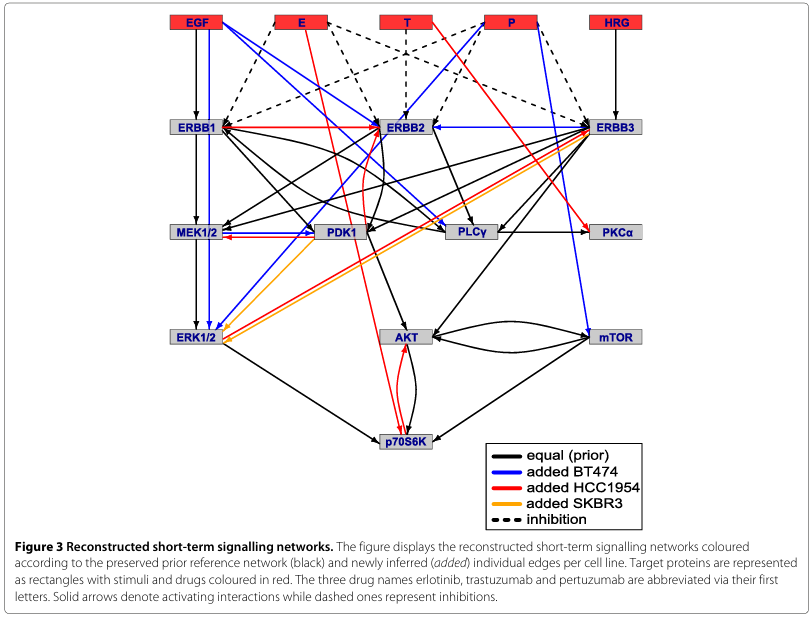

In [1]:
from IPython.display import Image, display

display(Image(filename='Fig_3_der_Heyde_2014.png'))

### 1. Effective graph

#### 1. 1 Edge effectiveness computation

##### Import modules

In [1]:
import pandas as pd
import networkx as nx

# Cana
from cana.boolean_network import BooleanNetwork
from cana.datasets.bio import BT474_ErbB_S

##### Read the BT474 Breast Cell Line model

In [2]:
B = BT474_ErbB_S()

##### Compute edge effectiveness

In [3]:
# Parameter settings

# threshold (float) – Only return edges above a certain effective connectivity threshold. 
#  This is usefull when computing graph measures at diffent levels.
threshold=0.0
EG = B.effective_graph(threshold=threshold)

In [4]:
# Display computed edge effectiveness
nodes=B.nodes
edge_data = [(nodes[u].name, nodes[v].name, EG[u][v]['weight']) for u, v in EG.edges()]

df = pd.DataFrame(edge_data, columns=['Source', 'Target', 'Edge effectiveness'])
df = df.sort_index(ascending=True)
df
top = df.head(5)
bottom = df.tail(5)

ellipsis = pd.DataFrame({col: ["..."] for col in df.columns}, index=["..."])

df_edge_effectiveness = pd.concat([top, ellipsis, bottom])
df_edge_effectiveness

,Source,Target,Edge effectiveness
0,PKCa,PKCa,0.625
1,MEK1_2,MEK1_2,0.296875
2,MEK1_2,ERK1_2,0.296875
3,MEK1_2,PDK1,0.225
4,p70S6K,p70S6K,0.296875
...,...,...,...
46,EGF,ERK1_2,0.296875
47,EGF,ERBB1,0.145833
48,EGF,ERBB2,0.095052
49,EGF,PLCg,0.225


#### 1. 2 Effective graph visualization

##### Effective Graph: BT474 Breast Cell Line Short-term ErbB Network


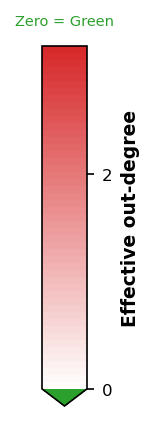

In [5]:
from cana.drawing.effective_graph import visualize_effective_graph
model_name = "BT474 Breast Cell Line Short-term ErbB Network"

# Set each node's location along with Figure 3 in der Heyde et al, 2014
manual_pos = {
    'EGF': (0, 4), 'erlotinib': (1.5, 4), 'trastuzumab': (3, 4), 'pertuzumab': (4.5, 4), 'HRG': (6, 4),
    'ERBB1': (0, 3), 'ERBB2': (3, 3), 'ERBB3': (6, 3),
    'MEK1_2': (0, 2), 'PDK1': (2, 2), 'PLCg': (4, 2), 'PKCa': (6, 2), 
    'ERK1_2': (0, 1), 'AKT': (3, 1), 'mTOR': (6, 1),
    'p70S6K': (3, 0)
}

threshold=0.0
EG = B.effective_graph(threshold=threshold)

visualize_effective_graph(EG, model_name, threshold, manual_pos)

In [6]:
# Display edges with source as 'pertuzumab'
edge_data = [(nodes[u].name, nodes[v].name, EG[u][v]['weight']) for u, v in EG.edges() if nodes[u].name.lower() == 'pertuzumab']
pd.DataFrame(edge_data, columns=['Source', 'Target', 'Edge effectiveness'])

,Source,Target,Edge effectiveness
0,pertuzumab,mTOR,0.416667
1,pertuzumab,ERK1_2,0.296875
2,pertuzumab,ERBB3,0.520833
3,pertuzumab,ERBB1,0.572917
4,pertuzumab,ERBB2,0.386719
5,pertuzumab,pertuzumab,1.000000


In the effective graph visualization, each edge width represents its edge effectiveness.

Each node color represents fffective out-degree of a node, the sum of edge effectiveness of the node.

Here, node pertuzumab has maximum effective out-degree, 3.194, as sum of

#### 1. 3 Threshold Effective graph visualization

By setting threshold parameter with specific values, you can see the threshold effective graph with edges whose edge effectiveness is above the threshold.

##### Threshold Effective Graph: BT474 Breast Cell Line Short-term ErbB Network
**Edge Weight Threshold:** 0.4


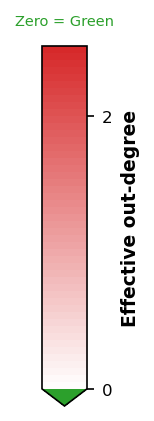

In [7]:
# Visualize edges with weight larger than threshold parameter, in this case, 0.4
threshold=0.4
EG04 = B.effective_graph(threshold=threshold)
visualize_effective_graph(EG04, model_name, threshold, manual_pos)

### 2. Conditional effective graph

with loaded the BT474 Breast Cell Line model

In [8]:
#### Drug nodes and their IDs
drugs = [11, 12, 13]
for i in drugs:
    print(f"Index {i}: {B.nodes[i].name}")

Index 11: trastuzumab
Index 12: pertuzumab
Index 13: erlotinib


In [9]:
#### Growth factor nodes (always set as 1 in the reference) and their IDs
growth_factors = [14, 15]
for i in growth_factors:
    print(f"Index {i}: {B.nodes[i].name}")

Index 14: HRG
Index 15: EGF


#### 2. 1 Compute edge effectiveness with baseline condition

In [10]:
# Parameter settings
# conditioned_nodes (dict) – a dictionary mapping node ids to their conditioned states. dict of form { nodeid : nodestate }
conditioned_nodes={14:1, 15:1} # Two growth factors HRG: ON, EGF: ON

# threshold (float) – Only return edges above a certain effective connectivity threshold. 
# This is usefull when computing graph measures at diffent levels.
threshold = 0.0 # gain all edges

EG_cn = B.conditional_effective_graph(conditioned_nodes=conditioned_nodes, threshold=threshold)

In [11]:
# Display computed edge effectiveness
nodes=B.nodes
edge_data = [(nodes[u].name, nodes[v].name, EG_cn[u][v]['weight']) for u, v in EG_cn.edges()]

df = pd.DataFrame(edge_data, columns=['Source', 'Target', 'Edge effectiveness'])
df = df.sort_index(ascending=True)
top = df.head(5)
bottom = df.tail(5)

ellipsis = pd.DataFrame({col: ["..."] for col in df.columns}, index=["..."])

df_edge_effectiveness_baseline = pd.concat([top, ellipsis, bottom])
df_edge_effectiveness_baseline

,Source,Target,Edge effectiveness
0,MEK1_2,MEK1_2,0.296875
1,MEK1_2,PDK1,0.225
2,mTOR,mTOR,0.416667
3,mTOR,AKT,0.296875
4,ERK1_2,p70S6K,0.296875
...,...,...,...
30,EGF,ERK1_2,0.296875
31,EGF,ERBB1,0.145833
32,EGF,ERBB2,0.095052
33,EGF,PLCg,0.225


The number of edges decreases from **51** to **35**, meaning that there are 16 edges which become fully redundant because of the baseline conditioning.

#### 2. 2 Conditional effective graph visualization

Visualize Conditional effective graph with baseline condition

<class 'networkx.classes.digraph.DiGraph'>


##### Conditional Effective Graph: BT474 Breast Cell Line Short-term ErbB Network
**Condition:** HRG: 1, EGF: 1

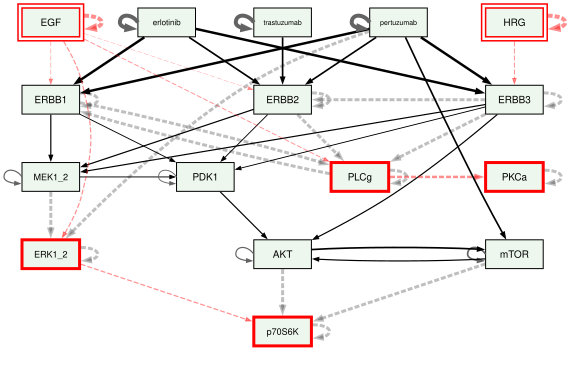

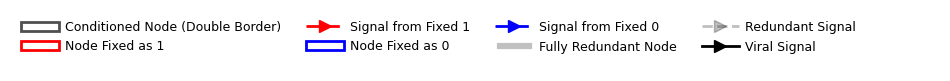

In [12]:
from cana.drawing.effective_graph import visualize_conditional_effective_graph
threshold = 0.0
EG0 = B.conditional_effective_graph(threshold=threshold)

conditioned_nodes={14:1, 15:1} # Two growth factors HRG: ON, EGF: ON
EG_cn = B.conditional_effective_graph(conditioned_nodes=conditioned_nodes, threshold=threshold)

# Optinal: Create conditioning string for visualization
node_strings = [f"{B.nodes[i].name}: {state}" for i, state in conditioned_nodes.items()]
conditioned_str = ", ".join(node_strings)

visualize_conditional_effective_graph(EG_cn, EG0, conditioned_nodes, model_name, conditioned_str, manual_pos)

Visualize Conditional effective graph with baseline + three drug administrations

<class 'networkx.classes.digraph.DiGraph'>


##### Conditional Effective Graph: BT474 Breast Cell Line Short-term ErbB Network
**Condition:** trastuzumab: 1, pertuzumab: 1, erlotinib: 1, HRG: 1, EGF: 1

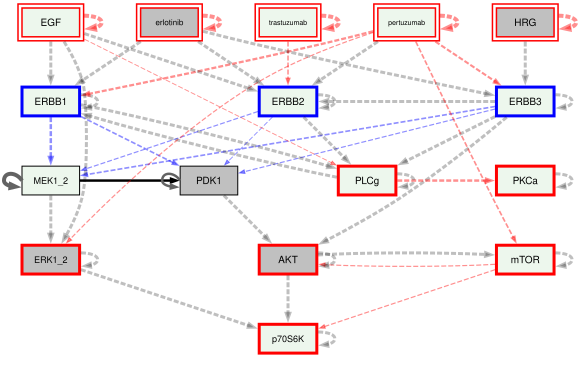

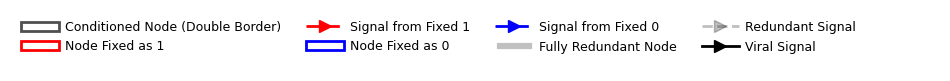

In [13]:
conditioned_nodes={11:1, 12:1, 13:1, # Three drugs pertuzumab: ON, erlotinib: OFF, trastuzumab: OFF
                   14:1, 15:1}       # Two growth factors HRG: ON, EGF: ON

EG_cn = B.conditional_effective_graph(conditioned_nodes=conditioned_nodes, threshold=threshold)

# Optinal: Create conditioning string for visualization
node_strings = [f"{B.nodes[i].name}: {state}" for i, state in conditioned_nodes.items()]
conditioned_str = ", ".join(node_strings)

visualize_conditional_effective_graph(EG_cn, EG0, conditioned_nodes, model_name, conditioned_str, manual_pos)